<hr/>
<b>Nombre</b>: Jesus D Serpa Pajaro


## Enunciado

**Objetivo**: Estudiar la dinámica del péndulo doble utilizando los métodos de Lagrange y Hamilton.

Un péndulo doble es un sistema formado por 2 partículas puntuales de masas $m_1$ y $m_2$ unidas por varillas inextensibles de longitudes $L_1$ y $L_2$. La varilla $L_1$ esta fija a un punto del espacio.

**Procedimiento**:

**Parte 1. La receta de Lagrange**

1. Para este sistema identifique:

  - Número de partículas: _____________
  - Número de coordenadas: _____________
  - Número de restricciones: _____________
  - Número de grados de libertad: _____________

2. Escriba las ecuaciones que describen las restricciones del sistema.

3. Identifique las variables generalizadas del sistema y explique por qué esas variables son apropiadas para describir el sistema con el método de Lagrange.

4. Escriba las ecuaciones que permiten transformar de las variables generalizadas $\{q_j\}_M$ a las coordenadas $\{\vec r_i\}_N$ y viceversa (transformación inversa).

5. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ calcule la función de energía cinética para el sistema. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.

6. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ y las componentes cartesianas de las fuerzas que actúan sobre las partículas, determine las fuerzas generalizadas. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.

7. Usando los resultados en 5 y en 6, escriba las ecuaciones de movimiento del sistema. Es normal que las ecuaciones se escriban como la segunda derivada de cada variable generalizada como función de las primeras derivada de las variables generalizadas y las variables generalizadas en sí.  Es decir las ecuaciones deben tener la forma:

  $$
  \ddot q_j = f_j (t,\{q_j\}_M,\{\dot q_j\}_M)
  $$


**Parte 2. Lagrangiano**

1. Encuentre la forma de la función potencial de la que derivan las fuerzas generalizadas del sistema.

2. Con la función potencial y la función lagrangiana, escriba el lagrangiano del sistema.

3. Deduzca, a partir de las ecuaciones de Euler-Lagrange, las ecuaciones de movimiento y verifique que coinciden con las ecuaciones de movimiento obtenidas a partir de las ecuaciones de Lagrange.

4. Evalúe las simetrías del lagrangiano:
  - ¿Tiene simetría de traslación?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene simetría de rotación?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene simetría temporal?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene variables cíclicas? ¿cuáles?: _________
  - Escriba explícitamente la función de Jacobi $h(t,\{q_j\}_M,\{\dot q_j\}_M)$ del sistema y diga si es constante o no.

**Parte 3. Hamiltoniano**

1. Escriba los momentos generalizados $\{p_j\}_M$ del sistema como función de las velocidades generalizadas $\{q_j\}_M$ del sistema.

2. Escriba la función de energía cinética en función de $\{p_j\}_M$.

3. Escriba el Lagrangianop $\{L_{qp}(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.

4. Escriba el Hamiltoniano $\{H(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.

5. A partir del Hamiltoniano escriba explícitamente las ecuaciones de movimiento usando las ecuaciones canónicas.

**Parte 4. Experimentos numéricos**

1. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la **parte 1**. Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.

2. Compruebe con una solución particular , que las constantes de movimiento identificadas del sistema en la **parte 2**, son en realidad constantes.

3. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la **parte 3**. Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.

4. El espacio de fases del sistema tiene muchas dimensiones. Se puede reducir si si fijan algunas variables del sistema. Fije en 0 el valor de las variables y momentos generalizados de la partícula 1 y gráfique contornos del Hamiltoniano en el espacio de fase resultante con las variables y momentos generalizados de la partícula 2.

5. Es bien sabido que el péndulo doble experimenta caos. Vamos a comprobarlo. Escoja condiciones iniciales arbitrarias para las variables (use las variables del formalismo Hamiltoniano). Grafique la evolución en el tiempo de las variables generalizadas de ambas partículas. Cambie ahora sutilmente las condiciones iniciales y estudie la evolución a largo plazo de las variables generalizadas.  Haga una animación que muestre la evolución del sistema con condiciones sutilmente diferentes como la que aparece [aquí](https://en.wikipedia.org/wiki/Double_pendulum#/media/File:Demonstrating_Chaos_with_a_Double_Pendulum.gif).

## Solución

Instalamos paquetes a utilizar

In [ ]:
!pip install -q pymcel celluloid

Importamos la librerias a utilizar

In [ ]:
import pymcel as pc
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from celluloid import Camera
from IPython.display import HTML
from scipy.integrate import odeint

### Parte 1


Un péndulo doble es un sistema formado por 2 partículas puntuales de masas $m_1$ y $m_2$ unidas por varillas inextensibles de longitudes $L_1$ y $L_2$. La varilla $L_1$ esta fija a un punto del espacio.

1. Para este sistema identifique:

Para el sistema del pedulo doble tenemos:
  - Número de partículas: 2
  - Número de coordenadas: 6
  - Número de restricciones: 4
  - Número de grados de libertad: 2

2. Escriba las ecuaciones que describen las restricciones del sistema. \\
Restrisccion de este problema son las Longitudes $L_1$ y $L_2$ son contantes, y que las coordenada en z de casa partica son iguales a cero.



In [ ]:
z1 = 0
z2 = 0

3. Identifique las variables generalizadas del sistema y explique por qué esas variables son apropiadas para describir el sistema con el método de Lagrange.



Las variables generalizadas para este sistema $q_1$ y $q_2$ se puedes indetifica como $q_1 = \theta_1$ y $q_2 = \theta_2$ ya que son variables que son independientes una de las otras por lo tanto son las mas adecuadas para trabajar como las variables generalizadas

4. Escriba las ecuaciones que permiten transformar de las variables generalizadas $\{q_j\}_M$ a las coordenadas $\{\vec r_i\}_N$ y viceversa (transformación inversa).




1.   Ecuacion de transformacion de variables generalizadas a las coordenadas
*   Para la masa 1
$$ x_1 = L_1 sen(\theta_1)$$

$$ y_2 = -L_2 cos(\theta_2)$$

*   Para la masa 2
$$ x_2 = L_2 sin(\theta_1) + L_2 sin(\theta_2)$$

$$ y_2 =-L_1 cos(\theta_1) - L_2 cons(\theta_2)$$

2.   Ecuaciones de traformacion de coordenadas a variables generalizadas


*   
Para la masa 1
$$ \theta_1 = tan^{-1}\left(\frac{y_1}{x_1} \right)$$

*   Para la masa 2
$$ \theta_2 = tan^{-1}\left(\frac{y_2}{x_2} \right)$$



5. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ calcule la función de energía cinética para el sistema. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.



Primeramente definimos la funcion de energia cinetica, la cual se define como

$$ T = \frac{1}{2}m_1 \dot{x_1}^2 + \frac{1}{2}m_1 \dot{y_1}^2 + \frac{1}{2}m_2 \dot{x_2}^2 + \frac{1}{2}m_2 \dot{2_2}^2  $$

definimos los simbolos en sympy

In [ ]:
t = sp.symbols('t')
g = sp.symbols('g')
q1 = sp.Function(r'\theta_1')(t)
q2 = sp.Function(r'\theta_2')(t)
L1 = sp.symbols(r'L_1')
L2 = sp.symbols(r'L_2')
m1 = sp.symbols(r'm_1')
m2 = sp.symbols(r'm_2')


#coordenadas
x1 = L1 * sp.sin(q1)
y1 = -L1 * sp.cos(q1)

x2 = L1 * sp.sin(q1) + L2 * sp.sin(q2)
y2 = - L1 * sp.cos(q1) - L2 * sp.cos(q2)

#derivadas
x1p = sp.diff(x1,t)
y1p = sp.diff(y1,t)

x2p = sp.diff(x2,t)
y2p = sp.diff(y2,t)
x1p

L_1*cos(\theta_1(t))*Derivative(\theta_1(t), t)

Calculamos la funcion de energia cinetica

In [ ]:
T = 0.5 *( m1 * x1p**2 + m1 * y1p**2 )+ 0.5 * ( m2 * x2p**2 + m2 * y2p**2)
T.simplify()

0.5*L_1**2*m_1*Derivative(\theta_1(t), t)**2 + 0.5*L_1**2*m_2*Derivative(\theta_1(t), t)**2 + 1.0*L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) + 0.5*L_2**2*m_2*Derivative(\theta_2(t), t)**2

6. Usando `SymPy` escriba una rutina que, dadas las ecuaciones de transformación  $\{\vec r_i(\{q_j\}_M)\}_N$ y las componentes cartesianas de las fuerzas que actúan sobre las partículas, determine las fuerzas generalizadas. Intente que la rutina sea tan general posible que pueda ser aplicada a otros sitstemas.


Calculamos la fuerza generalizada usando la siguiente ecuacion

$$ Q_j = \sum_i \vec{F_i}  ⋅ \frac{δ \vec{r_i}}{ δ q_j}$$
$$ Q_1= \vec{F_1}  ⋅ \left(  \frac{δx_1}{δq_1} +  \frac{δy_1}{δq_1}\right) +  \vec{F_2}  ⋅ \left(  \frac{δx_2}{δq_1} +  \frac{δy_2}{δq_1}\right) $$

Calculamos primeramenta las derivadas

In [ ]:
dx1q1 = sp.diff(x1,q1)
dy1q1 = sp.diff(y1,q1)

dx2q1 = sp.diff(x2,q1)
dy2q1 = sp.diff(y2,q1)


dx1q2 = sp.diff(x1,q2)
dy1q2 = sp.diff(y1,q2)

dx2q2 = sp.diff(x2,q2)
dy2q2 = sp.diff(y2,q2)


Definimos el vector de la fuerza de cada particula y el y la derivada de r con respecto a q

In [ ]:
F1 = [0, -g*m1]
F2 = [0, -g*m2]

dr1q1 = [dx1q1, dy1q1]
dr2q1 = [dx2q1, dy2q1]

dr1q2 = [dx1q2, dy1q2]
dr2q2 = [dx2q2, dy2q2]

In [ ]:
Q1 = np.dot(F1, dr1q1 ) + np.dot(F2, dr2q1)
Q2 = np.dot(F1, dr1q2 ) + np.dot(F2, dr2q2)

definimos las derivadas de las q

In [ ]:
dq1 = sp.diff(q1,t)
dq2 = sp.diff(q2,t)

calculamos las derivadas de la funcion de energia cinetica

In [ ]:
dTq1 = sp.diff(T,q1)
dTq2 = sp.diff(T,q2)

dTdq1 = sp.diff(T,dq1)
dTdq2 = sp.diff(T,dq2)

dtdTdq1 = sp.diff(dTdq1,t)
dtdTdq2 = sp.diff(dTdq2,t)

Calculamos la fuerza generalizada

In [ ]:
Q_1 = ( dtdTdq1 - dTq1 )
Q_2 = ( dtdTdq2 - dTq2 )

Encontramos las


7. Usando los resultados en 5 y en 6, escriba las ecuaciones de movimiento del sistema. Es normal que las ecuaciones se escriban como la segunda derivada de cada variable generalizada como función de las primeras derivada de las variables generalizadas y las variables generalizadas en sí.  Es decir las ecuaciones deben tener la forma:

  $$
  \ddot q_j = f_j (t,\{q_j\}_M,\{\dot q_j\}_M)
  $$

Definimos la segunda derivada de las variables generalizadas

In [ ]:
ddq1 = sp.diff(dq1,t)
ddq2 = sp.diff(dq2,t)

Encontramos las ecuaciones de movimiento

In [ ]:
ddθ1 = sp.solve(Q_1 - Q1, ddq1)[0]
ddθ2 = sp.solve(Q_2 - Q2, ddq2)[0]

In [ ]:
ddθ1

-(L_2*m_2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), t)**2 + L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), (t, 2)) + g*m_1*sin(\theta_1(t)) + g*m_2*sin(\theta_1(t)))/(L_1*(m_1 + m_2))

In [ ]:
ddθ2

(L_1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2 - L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), (t, 2)) - g*sin(\theta_2(t)))/L_2

### Parte 2

1. Encuentre la forma de la función potencial de la que derivan las fuerzas generalizadas del sistema.



In [ ]:
U =m1 * g * y1 + m2*g*y2
U

-L_1*g*m_1*cos(\theta_1(t)) + g*m_2*(-L_1*cos(\theta_1(t)) - L_2*cos(\theta_2(t)))

2. Con la función potencial y la función lagrangiana, escriba el lagrangiano del sistema.



Conociendo que el lagrangiano se calcula como $$L = T - U$$
Calculamos el lagrangiano

In [ ]:
L = T - U
L.simplify()

0.5*L_1**2*m_1*Derivative(\theta_1(t), t)**2 + 0.5*L_1**2*m_2*Derivative(\theta_1(t), t)**2 + 1.0*L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) + 1.0*L_1*g*m_1*cos(\theta_1(t)) + 1.0*L_1*g*m_2*cos(\theta_1(t)) + 0.5*L_2**2*m_2*Derivative(\theta_2(t), t)**2 + 1.0*L_2*g*m_2*cos(\theta_2(t))

3. Deduzca, a partir de las ecuaciones de Euler-Lagrange, las ecuaciones de movimiento y verifique que coinciden con las ecuaciones de movimiento obtenidas a partir de las ecuaciones de Lagrange.

Ecuaciones de Euler-lagrange se calcula como

$$ \frac{d}{dt} \left(\frac{\delta L }{\delta \dot{q_j}}\right) - \frac{\delta L}{ \delta q_j} = 0 $$

Calculamos las ecuaciones de Euler-lagrange

In [ ]:
dLq1 = sp.diff(L,q1)
dLq2 = sp.diff(L,q2)

dLdq1 = sp.diff(L,dq1)
dLdq2 = sp.diff(L,dq2)

dtdLdq1 = sp.diff(dLdq1,t)
dtdLdq2 = sp.diff(dLdq2,t)

Sacamos las ecuaciones de movimiento

In [ ]:
Lq1 =  sp.solve(dtdLdq1 - dLq1,ddq1 )[0]
Lq2 =  sp.solve(dtdLdq2 - dLq2,ddq2 )[0]

In [ ]:
Lq1

-(L_2*m_2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), t)**2 + L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), (t, 2)) + g*m_1*sin(\theta_1(t)) + g*m_2*sin(\theta_1(t)))/(L_1*(m_1 + m_2))

In [ ]:
Lq2

(L_1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2 - L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), (t, 2)) - g*sin(\theta_2(t)))/L_2

A partir de esto confirmamos que son las mismas ecuaciones de movimiento


4. Evalúe las simetrías del lagrangiano:
  - ¿Tiene simetría de traslación?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene simetría de rotación?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene simetría temporal?: _________ en caso afirmativo ¿cuáles son las constantes (cuadraturas) asociadas?: _________
  - ¿Tiene variables cíclicas? ¿cuáles?: _________
  - Escriba explícitamente la función de Jacobi $h(t,\{q_j\}_M,\{\dot q_j\}_M)$ del sistema y diga si es constante o no.

funcion de jacobi

In [ ]:
hj = sp.diff(L, dq1) * dq1 + sp.diff(L, dq2) * dq2 - L
hj.simplify()

0.5*L_1**2*m_1*Derivative(\theta_1(t), t)**2 + 0.5*L_1**2*m_2*Derivative(\theta_1(t), t)**2 + 1.0*L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) - 1.0*L_1*g*m_1*cos(\theta_1(t)) - 1.0*L_1*g*m_2*cos(\theta_1(t)) + 0.5*L_2**2*m_2*Derivative(\theta_2(t), t)**2 - 1.0*L_2*g*m_2*cos(\theta_2(t))

### Parte 3

**Parte 3. Hamiltoniano**

1. Escriba los momentos generalizados $\{p_j\}_M$ del sistema como función de las velocidades generalizadas $\{q_j\}_M$ del sistema.


Definimos a  $\{p_j\}_M$ como  $$ p_j = \frac{\delta L }{\delta \dot{q_j}}$$

calculamos los momentos generalizados

In [ ]:
p1 = sp.Function(r'p_1')(t)
p2 = sp.Function(r'p_2')(t)

p_1 = dLdq1.copy()
p_2 = dLdq2.copy()


2. Escriba la función de energía cinética en función de $\{p_j\}_M$.



Primeramente a partir de la variable auxiliar encontramos la inversion para encontrar $\dot{q}$

In [ ]:
q̇1 = sp.solve(p1 - p_1,dq1)[0]
q̇2 = sp.solve(p2 - p_2,dq2)[0]

Escribribimos la funcion de energia cinetica en funcion de p

In [ ]:
Tp = T.subs({dq1: q̇1, dq2: q̇2})
Tp

0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*sin(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*sin(\theta_1(t))/(L_1*(m_1 + m_2)))**2 + 0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*cos(\theta_1(t))/(L_1*(m_1 + m_2)))**2 + 0.5*m_1*(-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))**2*sin(\theta_1(t))**2/(L_1**2*(m_1 + m_2)**2) + 0.5*m_1*(-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))**2*cos(\theta_1(t))**2/

3. Escriba el Lagrangianop $\{L_{qp}(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.



Para calcular el lagrangiano modificado reemplazamos el q̇ en la eciacion del lagrangiando calculada anteriormente

In [ ]:
Lqp = L.subs({dq1: q̇1, dq2: q̇2})
Lqp

L_1*g*m_1*cos(\theta_1(t)) - g*m_2*(-L_1*cos(\theta_1(t)) - L_2*cos(\theta_2(t))) + 0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*sin(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*sin(\theta_1(t))/(L_1*(m_1 + m_2)))**2 + 0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*cos(\theta_1(t))/(L_1*(m_1 + m_2)))**2 + 0.5*m_1*(-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))**2*sin(\theta_1(t))**2/(L_1**2*(m_1 + m_2)**2) + 0.5*m_1*(-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p

4. Escriba el Hamiltoniano $\{H(t,\{q_j\}_M,\{p_j\}_M)\}$ del sistema.


Para calcular el Hamiltoniano usamos la siguiente ecuacion $$ H = \sum_k p_k \dot{q_k} - L_{qp}$$

In [ ]:
H = (p1*q̇1 + p2*q̇2) - Lqp
H

-L_1*g*m_1*cos(\theta_1(t)) + g*m_2*(-L_1*cos(\theta_1(t)) - L_2*cos(\theta_2(t))) - 0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*sin(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*sin(\theta_1(t))/(L_1*(m_1 + m_2)))**2 - 0.5*m_2*(L_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_2(t)) + (-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))*cos(\theta_1(t))/(L_1*(m_1 + m_2)))**2 + (-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*p_2(t) - 0.5*m_1*(-L_1*L_2*m_2*(-L_1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)/L_2 + p_2(t)/(L_2**2*m_2))*cos(\theta_1(t) - \theta_2(t)) + p_1(t))**2*sin(\theta_1(t))**2/(L_1**2*(m_1 + m_2


5. A partir del Hamiltoniano escriba explícitamente las ecuaciones de movimiento usando las ecuaciones canónicas.

Las ecuaciones de Hamiltos se escriben de la sigueinte forma

$$\left\lbrace  \dot{q_j} = \frac{\delta H}{\delta q_j} \right\rbrace_M $$
$$\left\lbrace \dot{p_j} = \frac{\delta L_{qp}}{\delta q_j} \right\rbrace_M $$

In [ ]:
qh1 = sp.diff(H,q1)
qh2 = sp.diff(H,q2)

ph1 = sp.diff(Lqp,q1)
ph2 = sp.diff(Lqp,q2)

In [ ]:
qh1.simplify()

(L_1**3*L_2**2*g*(m_1 + m_2)**3*sin(\theta_1(t)) + L_1**3*L_2*(m_1 + m_2)**2*p_2(t)*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) + L_1*L_2**3*m_2*(m_1 + m_2)*p_1(t)*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), t) + 1.0*L_1*m_1*(L_1*(L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) - p_2(t))*cos(\theta_1(t) - \theta_2(t)) + L_2*p_1(t))*(2*L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) - p_2(t))*sin(\theta_1(t) - \theta_2(t)) - 1.0*(L_1*(m_1 + m_2)*(L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) - p_2(t))*sin(\theta_2(t)) - m_2*(L_1*(L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) - p_2(t))*cos(\theta_1(t) - \theta_2(t)) + L_2*p_1(t))*sin(\theta_1(t)))*(-L_1**2*L_2*(m_1 + m_2)*sin(\theta_1(t) - \theta_2(t))*sin(\theta_2(t))*Derivative(\theta_1(t), t) + L_1*(2*L_1*L_2*m_2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t) - p_2(t))*sin(\theta_1(t) - \theta_2(t))*sin(\thet

### Parte 4

**Parte 4. Experimentos numéricos**

1. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la **parte 1**. Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.


Pasamos las ecuaciones de movimiento de sympy a numpy

definimos una funcion para despejar la segunda derivada para cada una de las ecuaciones

Definimos la funicon para sacar las coordenadas dependiendo de las variables generalizadas


In [ ]:
def solucion(t, pos1, vel1, pos2, vel2, params):
    def eq(y, t, g, m1, m2, l1, l2):
        q1, dq1, q2, dq2 = y

        h1 = np.cos(q1 - q2)
        h2 = np.cos(q1 - 2 * q2)
        h3 = np.cos(2 * q1 - 2 * q2)

        num1 = (-g * (2 * m1 + m2) * np.sin(q1) - m2 * g * np.sin(q1 - 2 * q2) \
                - 2 * np.sin(q1 - q2) * m2 * (dq2**2 * l2 + dq1**2 * l1 * h1))
        den1 = l1 * (2 * m1 + m2 - m2 * h3)
        ddq1dt = num1 / den1

        num2 = 2 * np.sin(q1 - q2) * (dq2**2 * l1 * (m1 + m2) + g \
              * (m1 + m1 * m2) * np.cos(q1)\
              + dq2**2 * l2 * np.pi * m2 * np.cos(q1 - q2))
        den2 = l2 * (2 * m1 + m1 * m2 - m1 * m2 * h3)
        ddq2dt = num2 / den2

        return [dq1, ddq1dt, dq2, ddq2dt]

    # parametros
    g, m1, m2, l1, l2 = params

    # condiciones
    y0 = [pos1, vel1, pos2, vel2]

    # integramos
    sol = odeint(eq, y0, t, args=(g, m1, m2, l1, l2))

    q1 = sol[:, 0]
    q2 = sol[:, 2]

    x1 = l1 * np.sin(q1)
    y1 = -l1 * np.cos(q1)

    x2 = x1 + l2 * np.sin(q2)
    y2 = y1 - l2 * np.cos(q2)

    return x1, y1, x2, y2 , q1, q2, dq1, dq2

# Condiciones y parametros iniciales
g_ = 9.8
pos1 = 1
vel1 = 0
pos2 = 2
vel2 = 0
m_1 = 1
m_2 = 2
L_1 = 1
L_2 = 0.5
ts = np.linspace(0, 40, 1000)
params = [g_, m_1, m_2, L_1, L_2]

#soluciones del sistema
x1, y1, x2, y2 , q_1, q_2, dq_1, dq_2 = solucion(ts, pos1, vel1, pos2, vel2, params)


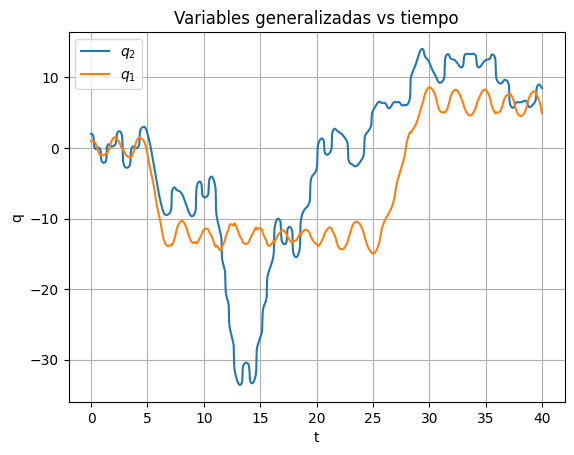

In [ ]:
plt.plot(ts,q_2,label= r'$q_2$')
plt.plot(ts,q_1, label= r'$q_1$')
plt.xlabel('t')
plt.ylabel('q')
plt.title('Variables generalizadas vs tiempo')
plt.legend()
plt.grid()

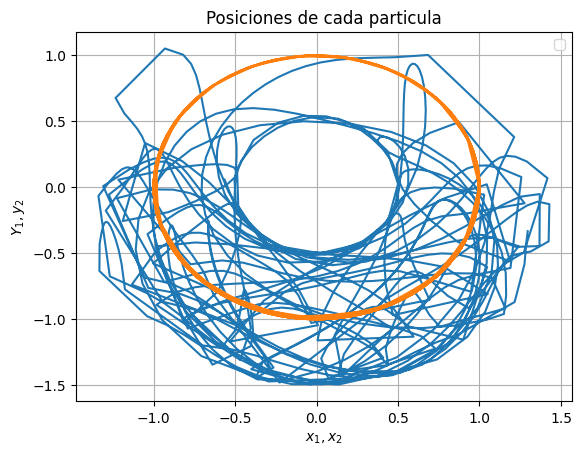

In [ ]:
plt.plot(x2,y2)
plt.plot(x1,y1)
plt.xlabel(r'$ x_1, x_2$')
plt.ylabel(r'$ Y_1 , y_2$')
plt.title('Posiciones de cada particula')
plt.legend()
plt.grid()

Graficamos

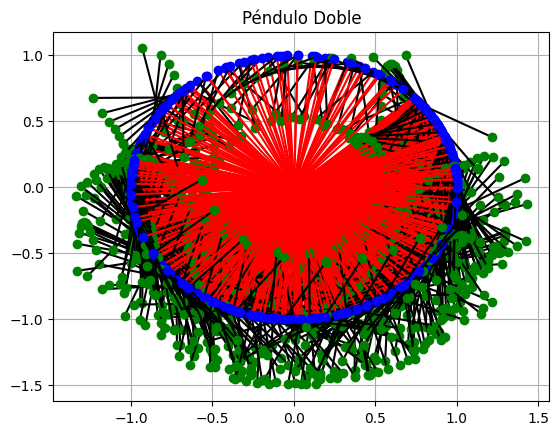

In [ ]:
fig, ax = plt.subplots()
c = Camera(fig)

for i in range(len(ts)):
  ax.plot([0, x1[i]], [0, y1[i]], 'r-')
  ax.plot([x1[i], x2[i]], [y1[i], y2[i]], 'k-')
  ax.plot(x2[i], y2[i], 'go')
  ax.plot(x1[i], y1[i], 'bo')
  ax.set_title('Péndulo Doble')
  c.snap()

plt.grid()
plt.show()

In [ ]:
anim = c.animate(interval = 100, blit=True)
HTML(anim.to_html5_video())

NOTA: Durante el procedimiento de la solucion de las ecuaciones calculadas anteriormente el montaje tuvo algunas dificultades al momento de pasar de sympy a numpy por lo tanto se decidio escribir las ecuaciones directamente para poder solucionar las ecuaciones de movimiento del sistema.


2. Compruebe con una solución particular , que las constantes de movimiento identificadas del sistema en la **parte 2**, son en realidad constantes.



Pasamos las ecuaciones de sympy a numpy


In [ ]:
Up = sp.lambdify((m1,m2,L1,L2,q1,q2,g),U)
K = sp.lambdify((m1,m2,L1,L2,q1,q2,dq1,dq2),T)

usamos la ecuacion para calular

In [ ]:
potencial = Up(m_1,m_2,L_1,L_2,q_1,q_2,g_)
cinetica = K(m_1,m_2,L_1,L_2,q_1,q_2,vel1,vel2)

E = cinetica + potencial
E

array([-1.18066488e+01, -1.20100636e+01, -1.26253685e+01, -1.36743098e+01,
       -1.52265450e+01, -1.75458854e+01, -2.32081089e+01, -2.79190020e+01,
       -2.96035340e+01, -3.15248359e+01, -3.36430153e+01, -3.58020287e+01,
       -3.77379485e+01, -3.89951348e+01, -3.89483135e+01, -3.74719925e+01,
       -3.51884778e+01, -3.26549595e+01, -3.01746132e+01, -2.79093636e+01,
       -2.59333895e+01, -2.41416153e+01, -1.77247183e+01, -1.36515818e+01,
       -1.18510920e+01, -1.07884866e+01, -1.02475641e+01, -1.01590777e+01,
       -1.04910472e+01, -1.12240690e+01, -1.23461132e+01, -1.38575968e+01,
       -1.57937005e+01, -1.83120212e+01, -2.23710066e+01, -3.03293809e+01,
       -3.14459412e+01, -3.29547220e+01, -3.46335594e+01, -3.62539797e+01,
       -3.75435312e+01, -3.81084164e+01, -3.73463466e+01, -3.48222211e+01,
       -3.12227184e+01, -2.74417031e+01, -2.38694050e+01, -2.06556419e+01,
       -1.78645020e+01, -1.55236985e+01, -1.36419961e+01, -1.22164487e+01,
       -1.12351462e+01, -

In [ ]:
Hj = sp.lambdify((m1,m2,L1,L2,q1,q2,dq1,dq2,g),hj)
jacobi = Hj(m_1,m_2,L_1,L_2,q_1,q_2,vel1,vel2,g_)
jacobi

array([-1.18066488e+01, -1.20100636e+01, -1.26253685e+01, -1.36743098e+01,
       -1.52265450e+01, -1.75458854e+01, -2.32081089e+01, -2.79190020e+01,
       -2.96035340e+01, -3.15248359e+01, -3.36430153e+01, -3.58020287e+01,
       -3.77379485e+01, -3.89951348e+01, -3.89483135e+01, -3.74719925e+01,
       -3.51884778e+01, -3.26549595e+01, -3.01746132e+01, -2.79093636e+01,
       -2.59333895e+01, -2.41416153e+01, -1.77247183e+01, -1.36515818e+01,
       -1.18510920e+01, -1.07884866e+01, -1.02475641e+01, -1.01590777e+01,
       -1.04910472e+01, -1.12240690e+01, -1.23461132e+01, -1.38575968e+01,
       -1.57937005e+01, -1.83120212e+01, -2.23710066e+01, -3.03293809e+01,
       -3.14459412e+01, -3.29547220e+01, -3.46335594e+01, -3.62539797e+01,
       -3.75435312e+01, -3.81084164e+01, -3.73463466e+01, -3.48222211e+01,
       -3.12227184e+01, -2.74417031e+01, -2.38694050e+01, -2.06556419e+01,
       -1.78645020e+01, -1.55236985e+01, -1.36419961e+01, -1.22164487e+01,
       -1.12351462e+01, -

Funcion de jacobi

3. Escriba un programa para resolver numéricamente las ecuaciones de movimiento obtenidas en la **parte 3**. Con condiciones iniciales apropiadas, resuelva las ecuaciones y haga una animación del movimiento del péndulo.



In [ ]:
dHp1 = (L2 * p1 - L1 * p2 * sp.cos(q1 - q2)) / (L1**2 * L2 * (m1 + m2 * sp.sin(q1 - q2)**2))
dHp2 = (-m2 * L2 * p1 * sp.cos(q1 - q2) + (m1 + m2) * L1 * p2) / (m2 * L1 * L2**2 * (m1 + m2 * sp.sin(q1 - q2)**2))

h1 = (p1 * p2 * sp.sin(q1 - q2)) / (L1 * L2 * (m1 + m2 * sp.sin(q1 - q2)**2))

h2 = (m2 * L2**2 * p1 + (m1 + m2) * L1**2 * p2**2 - 2 * m2 * L1 * L2 * p1 * p2 * sp.cos(q1 - q2)) / (2 * L1**2 * L2**2 * (m1 + m2 * sp.sin(q1 - q2)**2)**2)

dHq1 = -(m1 + m2) * g * L1 * sp.sin(q1) - h1 + h2 * sp.sin(2 * (q1 - q2))

dHq2 = -m2 * g * L2 * sp.sin(q2) + h1 - h2 * sp.sin(2 * (q1 - q2))

In [ ]:
dHp1_ = sp.lambdify((q1, q2, p1, p2, m1, m2, L1, L2, g), dHp1)
dHp2_ = sp.lambdify((q1, q2, p1, p2, m1, m2, L1, L2, g), dHp2)
dHq1_ = sp.lambdify((q1, q2, p1, p2, m1, m2, L1, L2, g), dHq1)
dHq2_ = sp.lambdify((q1, q2, p1, p2, m1, m2, L1, L2, g), dHq2)

def hamiltoniano(ts, q1_0, q2_0, p1_0, p2_0, params):

    def eqh(y, t, m1, m2, L1, L2, g):
        q1, q2, p1, p2 = y
        dq1dt = dHp1_(q1, q2, p1, p2, m1, m2, L1, L2, g)
        dq2dt = dHp2_(q1, q2, p1, p2, m1, m2, L1, L2, g)
        dp1dt = -dHq1_(q1, q2, p1, p2, m1, m2, L1, L2, g)
        dp2dt = -dHq2_(q1, q2, p1, p2, m1, m2, L1, L2, g)
        return [dq1dt, dq2dt, dp1dt, dp2dt]
    m1, m2, L1, L2, g = params

    y0 = [q1_0, q2_0, p1_0, p2_0]

    sol = odeint(eqh, y0, ts, args=(m1, m2, L1, L2, g))

    q1 = sol[:, 0]
    q2 = sol[:, 1]
    p1 = sol[:, 2]
    p2 = sol[:, 3]

    x1 = L1 * np.sin(q1)
    y1 = -L1 * np.cos(q1)

    x2 = x1 + L2 * np.sin(q2)
    y2 = y1 - L2 * np.cos(q2)
    return x1,y1,x2,y2

#condiciones
g_ = 9.8
m1_ = 1
m2_ = 1
L1_ = 1
L2_ = 1
ts = np.linspace(0, 20, 1000)
params = (m1_, m2_, L1_, L2_, g_)

q1_0 = 1
q2_0 = 1
p1_0 = 0
p2_0 = 0
y0 = [q1_0, q2_0, p1_0, p2_0]

x1h, y1h, x2h, y2h = hamiltoniano(ts, q1_0, q2_0, p1_0, p2_0, params)


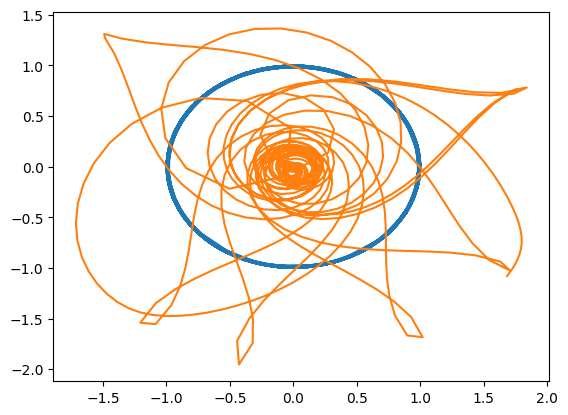

In [ ]:
plt.plot(x1h , y1h)
plt.plot(x2h , y2h)

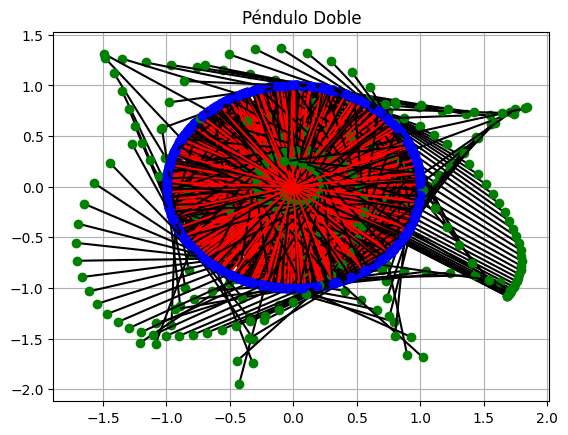

In [ ]:
fig, ax = plt.subplots()
c = Camera(fig)

for i in range(len(ts)):
  ax.plot([0, x1h[i]], [0, y1h[i]], 'r-')
  ax.plot([x1h[i], x2h[i]], [y1h[i], y2h[i]], 'k-')
  ax.plot(x2h[i], y2h[i], 'go')
  ax.plot(x1h[i], y1h[i], 'bo')
  ax.set_title('Péndulo Doble')
  c.snap()

plt.grid()
plt.show()